In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.head()


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [3]:
#Overview
print("Train shape:", train.shape)
print("Test shape :", test.shape)

print("\nTrain columns:\n", train.columns.tolist())
print("\nData types:\n", train.dtypes)

print("\nMissing values (train):\n", train.isna().sum())
print("\nMissing values (test):\n", test.isna().sum())


Train shape: (630000, 13)
Test shape : (270000, 12)

Train columns:
 ['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'exam_score']

Data types:
 id                    int64
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object

Missing values (train):
 id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

Missing values (test):
 i

In [4]:
#Summary statistics
train.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,630000.0,NaN,NaN,NaN,314999.5,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0
age,630000.0,NaN,NaN,NaN,20.545821,2.260238,17.0,19.0,21.0,23.0,24.0
gender,630000,3,other,211097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
course,630000,7,b.tech,131236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours,630000.0,NaN,NaN,NaN,4.002337,2.35988,0.08,1.97,4.0,6.05,7.91
class_attendance,630000.0,NaN,NaN,NaN,71.987261,17.430098,40.6,57.0,72.6,87.2,99.4
internet_access,630000,2,yes,579423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,630000.0,NaN,NaN,NaN,7.072758,1.744811,4.1,5.6,7.1,8.6,9.9
sleep_quality,630000,3,poor,213675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_method,630000,5,coaching,131697,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
import os
os.makedirs("../charts", exist_ok=True)


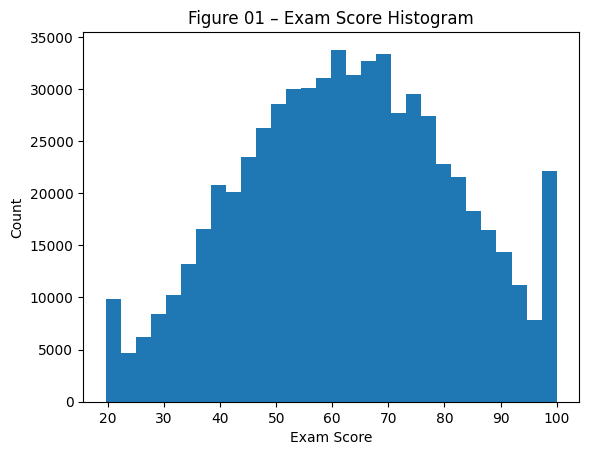

In [19]:
#Figure 01 — Exam score histogram
plt.figure()
plt.hist(train["exam_score"], bins=30)
plt.title("Figure 01 – Exam Score Histogram")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.savefig("../charts/Figure_01_exam_score_hist.png", dpi=200, bbox_inches="tight")
plt.show()


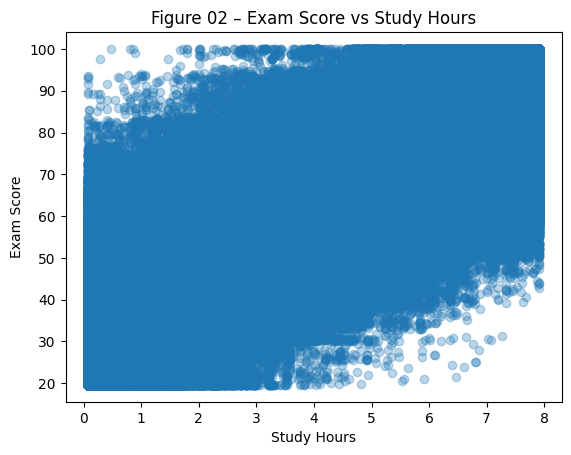

In [12]:
#Figure 02 — Score vs study hours Scatter Plot
plt.figure()
plt.scatter(train["study_hours"], train["exam_score"], alpha=0.3)
plt.title("Figure 02 – Exam Score vs Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.savefig("../charts/Figure_02_score_vs_study_hours.png", dpi=200, bbox_inches="tight")
plt.show()


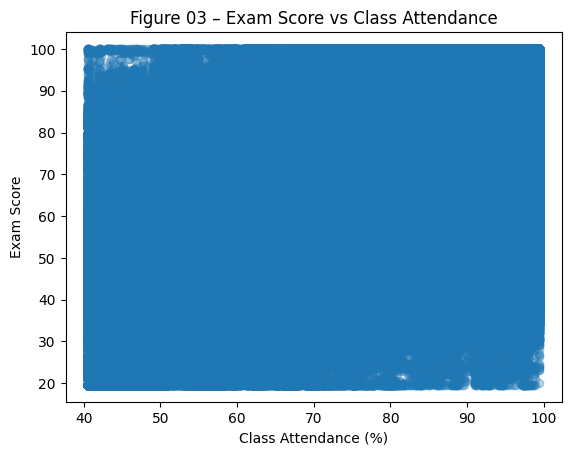

In [13]:
#Figure 03 — Score vs attendance Scatter Plot
plt.figure()
plt.scatter(train["class_attendance"], train["exam_score"], alpha=0.3)
plt.title("Figure 03 – Exam Score vs Class Attendance")
plt.xlabel("Class Attendance (%)")
plt.ylabel("Exam Score")
plt.savefig("../charts/Figure_03_score_vs_attendance.png", dpi=200, bbox_inches="tight")
plt.show()


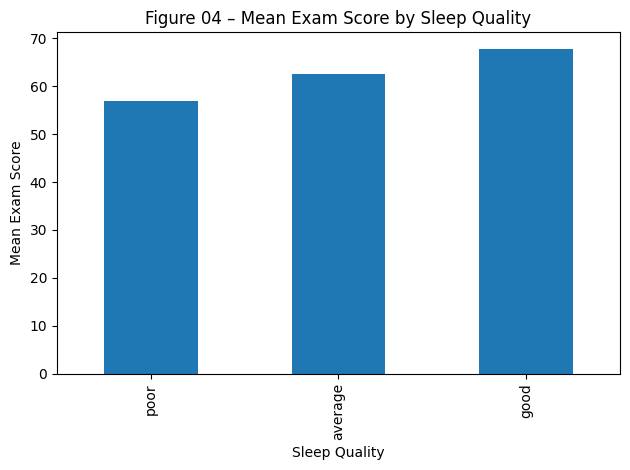

In [17]:
#Figure 04 — Score by sleep quality (boxplot)
means = train.groupby("sleep_quality")["exam_score"].mean().sort_values()

plt.figure()
means.plot(kind="bar")
plt.title("Figure 04 – Mean Exam Score by Sleep Quality")
plt.xlabel("Sleep Quality")
plt.ylabel("Mean Exam Score")
plt.tight_layout()
plt.savefig("../charts/Figure_04_mean_by_sleep_quality.png", dpi=200, bbox_inches="tight")
plt.show()


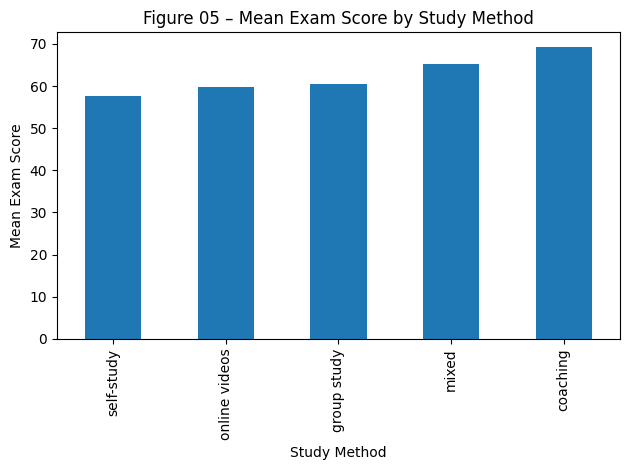

In [18]:
#Figure 05 — Mean Exam Score by Study Method
means = train.groupby("study_method")["exam_score"].mean().sort_values()

plt.figure()
means.plot(kind="bar")
plt.title("Figure 05 – Mean Exam Score by Study Method")
plt.xlabel("Study Method")
plt.ylabel("Mean Exam Score")
plt.tight_layout()
plt.savefig("../charts/Figure_05_mean_by_study_method.png", dpi=200, bbox_inches="tight")
plt.show()


In [20]:
#Figure 05 — Missing Values per Feature (bar chart)
miss = train.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]

if len(miss) == 0:
    print("No missing values found in training data.")
else:
    plt.figure()
    miss.plot(kind="bar")
    plt.title("Figure 05 – Missing Values per Feature")
    plt.xlabel("Feature")
    plt.ylabel("Missing Count")
    plt.tight_layout()
    plt.savefig("../charts/Figure_05_missing_values.png", dpi=200, bbox_inches="tight")
    plt.show()


No missing values found in training data.


C:\Users\user\AppData\Local\Temp\ipykernel_20536\1131710628.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats)


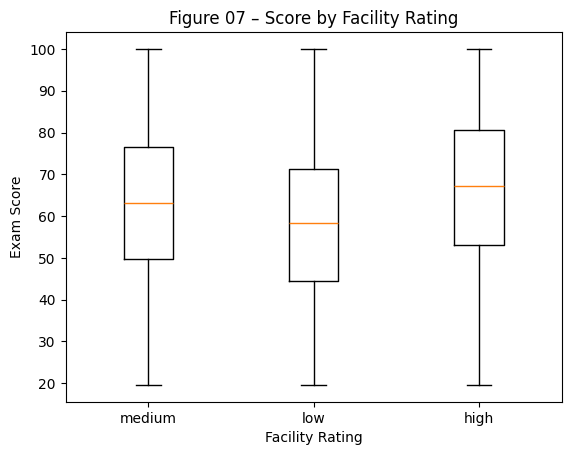

In [19]:
#Figure 07 — Score by facility rating
plt.figure()
cats = train["facility_rating"].value_counts().index.tolist()
data = [train.loc[train["facility_rating"] == c, "exam_score"] for c in cats]
plt.boxplot(data, labels=cats)
plt.title("Figure 07 – Score by Facility Rating")
plt.xlabel("Facility Rating")
plt.ylabel("Exam Score")
plt.savefig("../charts/Figure_07_score_by_facility_rating.png", dpi=200, bbox_inches="tight")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_20536\1068115844.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[c for c in cats if c in train["exam_difficulty"].unique()])


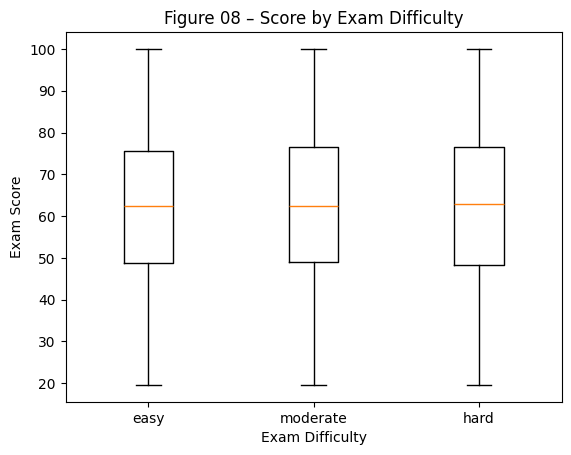

In [24]:
#Figure 08 — Score by exam difficulty
plt.figure()
cats = ["easy", "moderate", "hard"]
data = [train.loc[train["exam_difficulty"] == c, "exam_score"] for c in cats if c in train["exam_difficulty"].unique()]
plt.boxplot(data, labels=[c for c in cats if c in train["exam_difficulty"].unique()])
plt.title("Figure 08 – Score by Exam Difficulty")
plt.xlabel("Exam Difficulty")
plt.ylabel("Exam Score")
plt.savefig("../charts/Figure_08_score_by_exam_difficulty.png", dpi=200, bbox_inches="tight")
plt.show()


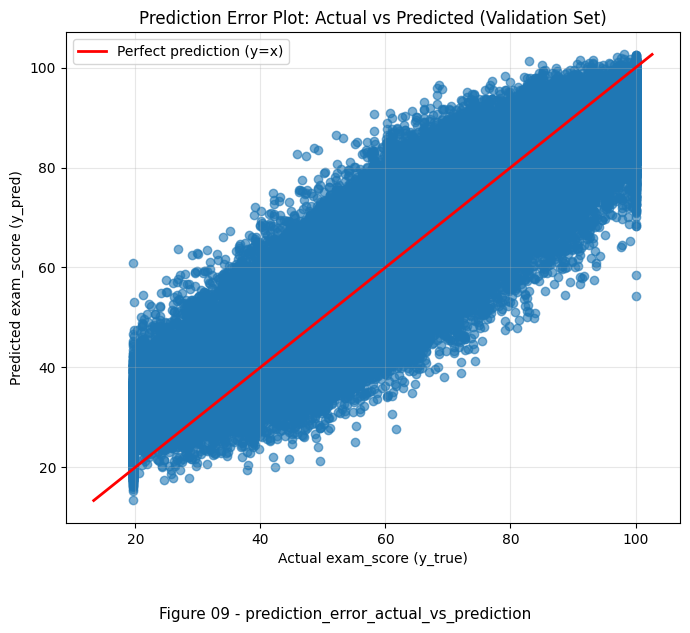

Saved plot to: ../charts\Figure09_prediction_error_actual_vs_prediction.png


In [32]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ----------------------------
# SETTINGS (edit if needed)
# ----------------------------
TRAIN_PATH = "../data/train.csv"
MODEL_PATH = "../models/model_xgb.joblib"   # change to ../models/model_v2.joblib if needed
TARGET_COL = "exam_score"
ID_COL = "id"

# Where to save chart images for your report
OUT_DIR = "../charts"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------
# LOAD DATA
# ----------------------------
df = pd.read_csv(TRAIN_PATH)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Keep feature columns consistent
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])

# Same split every time (reproducible)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# LOAD MODEL + PREDICT
# ----------------------------
model = joblib.load(MODEL_PATH)
y_pred = model.predict(X_val)

# ----------------------------
# PLOT: y_true vs y_pred
# ----------------------------
plt.figure(figsize=(7, 6))
plt.scatter(y_val, y_pred, alpha=0.6)
plt.xlabel("Actual exam_score (y_true)")
plt.ylabel("Predicted exam_score (y_pred)")
plt.title("Prediction Error Plot: Actual vs Predicted (Validation Set)")

# Perfect prediction line (RED)
min_v = min(y_val.min(), y_pred.min())
max_v = max(y_val.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], color="red", linewidth=2, label="Perfect prediction (y=x)")

plt.grid(True, alpha=0.3)
plt.legend()

# Caption (Figure label)
plt.figtext(0.5, -0.04, "Figure 09 - prediction_error_actual_vs_prediction",
            ha="center", fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)

save_path = os.path.join(OUT_DIR, "Figure09_prediction_error_actual_vs_prediction.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved plot to:", save_path)
